In [ ]:
import sys
import os

import torch

sys.path.append(os.path.abspath("../src"))

from models import SimpleCNN, ResNet18, DenseNet121, EfficientNetB0, MobileNetV2, ShuffleNetV2, SqueezeNet

from data import (
    prepare_full_dataframe, 
    prepare_data
 )

from utils import (
    get_device,
    load_experiment_outputs,
    save_experiment_outputs,
    get_experiment_outputs_path
 )

from train import run_training_pipeline

from experiement_types import Metrics, History, ModelOutput

import config

c:\Users\profb\Projects\cxr-model-benchmark\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
print(f"Python executable: {sys.executable}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Python executable: c:\Users\profb\Projects\cxr-model-benchmark\.venv\Scripts\python.exe
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


# Data Preprocessing

In [3]:
dataset_path = config.DATASET_PATH
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())
df["Finding Labels"].value_counts().head()

Dataset location: F:\Datasets\NIH_Chest_X-Rays
Total images: 112120
Unique patients: 30805


Finding Labels
No Finding      60361
Infiltration     9547
Atelectasis      4215
Effusion         3955
Nodule           2705
Name: count, dtype: int64

In [4]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [5]:
train_loader, val_loader, test_loader = prepare_data(df)
device = get_device()

Using CUDA (GPU)


# Model Individual Training/Testing

In [ ]:
model_registry = {
    "SimpleCNN": SimpleCNN,
    "ResNet18": lambda: ResNet18(num_classes=2, in_channels=1),
    "DenseNet121": lambda: DenseNet121(num_classes=2, in_channels=1),
    "EfficientNet-B0": lambda: EfficientNetB0(num_classes=2, in_channels=1),
    "MobileNetV2": lambda: MobileNetV2(num_classes=2, in_channels=1),
    "ShuffleNetV2": lambda: ShuffleNetV2(num_classes=2, in_channels=1),
    "SqueezeNet": lambda: SqueezeNet(num_classes=2, in_channels=1)
}
model_names = list(model_registry.keys())
model_builders = list(model_registry.values())

experiment_outputs_path = get_experiment_outputs_path()
experiment_outputs = load_experiment_outputs(experiment_outputs_path)
print(f"Loaded {len(experiment_outputs)} saved result(s) from {experiment_outputs_path}")

def train_and_store_model(index, live_plot=True):
    metrics, history = run_training_pipeline(
        model_names[index],
        model_builders[index],
        train_loader,
        val_loader,
        test_loader,
        device,
        live_plot=live_plot,
    )
    experiment_outputs[model_names[index]] = ModelOutput(
        metrics=Metrics(**metrics),
        history=History(**history),
    )
    save_experiment_outputs(experiment_outputs, experiment_outputs_path)
    print(f"Saved {model_names[index]} results to {experiment_outputs_path}")
    return experiment_outputs[model_names[index]]

## Simple CNN

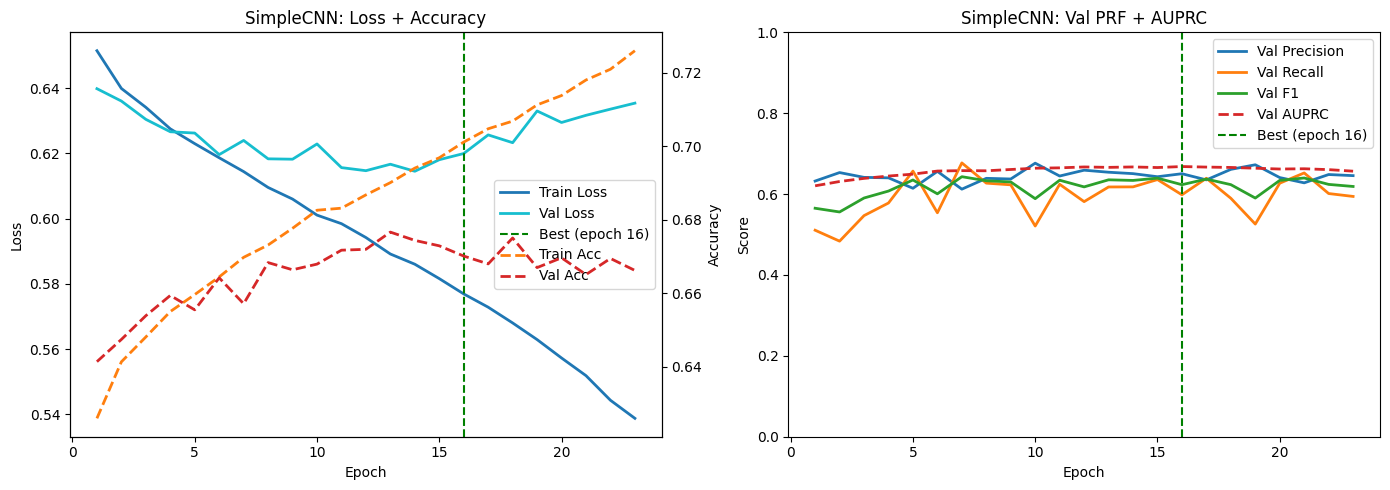

Early stopping at epoch 23 (patience 7 exceeded)


In [ ]:
train_and_store_model(0, live_plot=True)

## ResNet-18

In [ ]:
train_and_store_model(1, live_plot=True)


=== Training ResNet18 ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\profb/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 45.1MB/s]


KeyboardInterrupt: 

## DenseNet-121

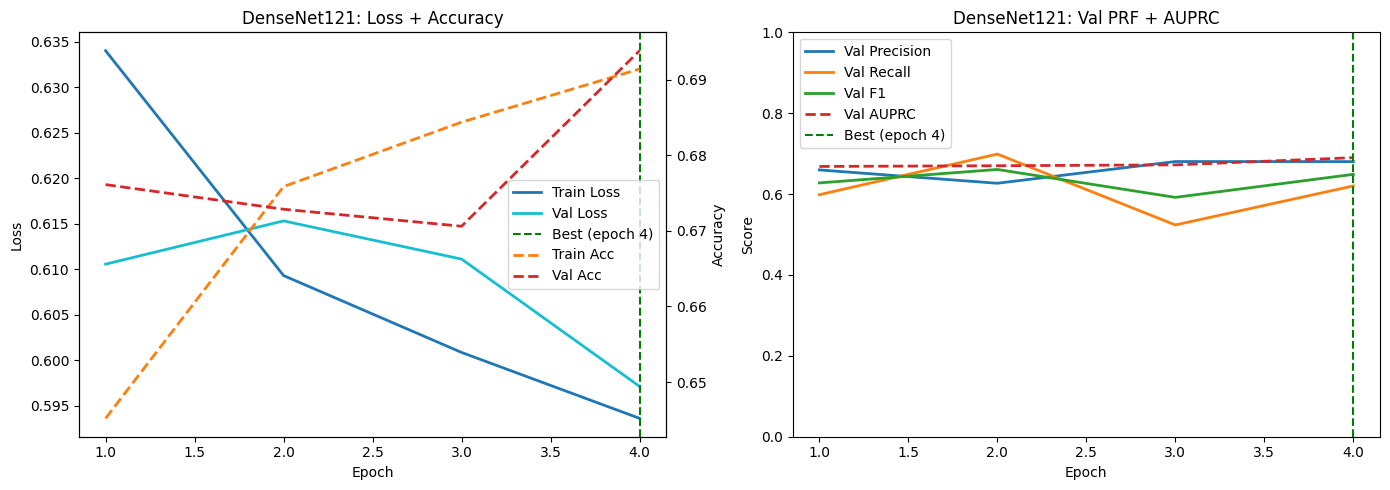

KeyboardInterrupt: 

In [ ]:
train_and_store_model(2, live_plot=True)

## EfficientNet-B0

In [ ]:
train_and_store_model(3, live_plot=True)

## MobileNet-V2

In [ ]:
train_and_store_model(4, live_plot=True)

## ShuffleNetV2

In [ ]:
train_and_store_model(5, live_plot=True)

## SqueezeNet

In [ ]:
train_and_store_model(6, live_plot=True)

# Model Comparison Plots
Visualize the test results for all models using bar plots for accuracy, precision, recall, and F1 score.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

experiment_outputs = load_experiment_outputs(experiment_outputs_path)
if not experiment_outputs:
    raise ValueError(
        f"No saved experiment outputs found at {experiment_outputs_path}. Run at least one training cell first."
    )

results_df = pd.DataFrame([
    vars(out.metrics) for out in experiment_outputs.values()
])

metrics = ["accuracy", "precision", "recall", "f1", "auprc"]

plt.figure(figsize=(12, 6))
results_melted = results_df.melt(
    id_vars="model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
 )
sns.barplot(data=results_melted, x="model", y="Score", hue="Metric")
plt.title("Model Comparison on Test Set")
plt.ylabel("Score")

min_score = results_melted["Score"].min()
max_score = results_melted["Score"].max()
padding = max(0.01, 0.08 * (max_score - min_score))
ymin = max(0.0, min_score - padding)
ymax = min(1.0, max_score + padding)
plt.ylim(ymin, ymax)

plt.legend(loc="lower right")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()